In [105]:
from sklearn.datasets import make_regression
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

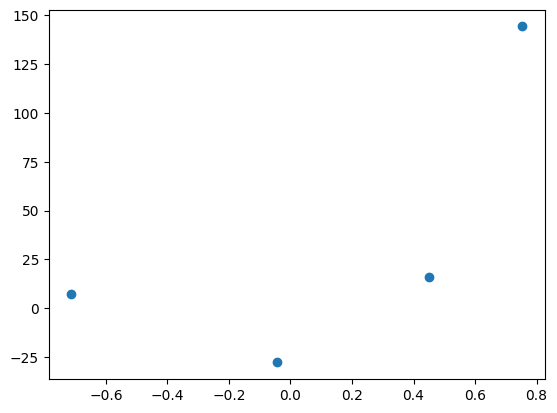

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [5]:
reg.coef_

array([78.35063668])

In [6]:
reg.intercept_

26.15963284313262

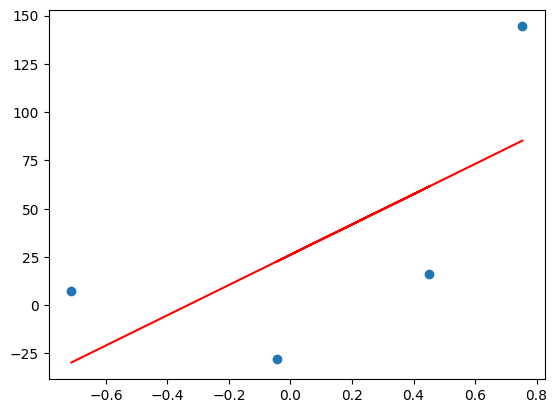

In [7]:

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [8]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35* X) + 100).reshape(4)

In [9]:
y_pred

array([ 44.18419163, 135.39949674,  96.51318381, 159.05759577])

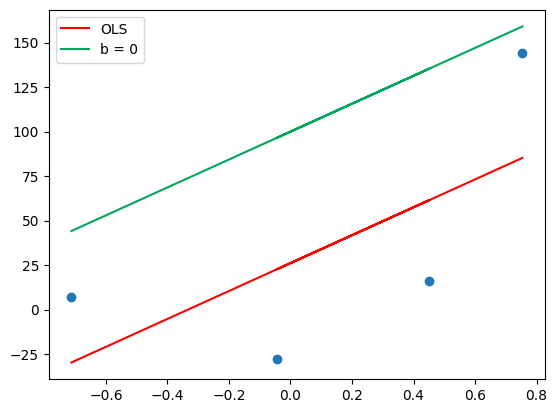

In [10]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()
     

In [11]:
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

590.7223659179078

In [12]:
lr= 0.1

step_size = loss_slope*lr
step_size

59.072236591790784

In [13]:
b = b - step_size
b

40.927763408209216

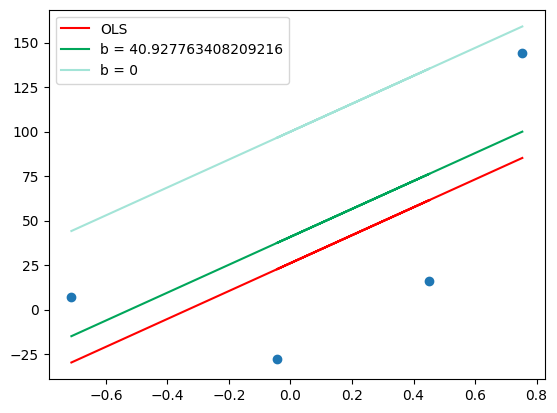

In [33]:

y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

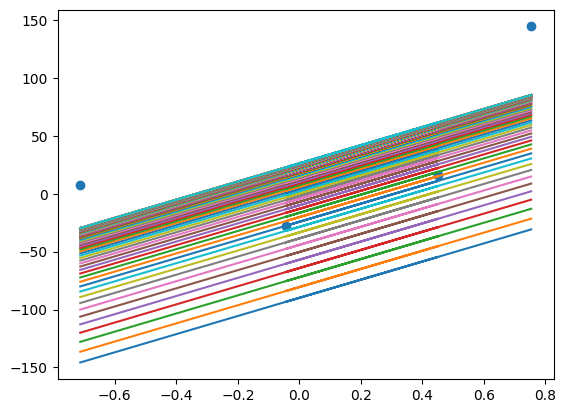

In [35]:
b = -100
m = 78.35
lr = 0.01

epochs = 100
for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)
    y_pred = m*X + b
    plt.plot(X,y_pred)
plt.scatter(X,y)

In [37]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [39]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

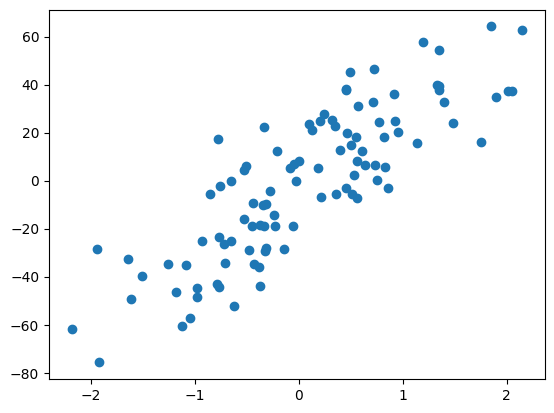

In [41]:
plt.scatter(X,y)

In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [45]:
from sklearn.linear_model import LinearRegression

In [47]:
lr = LinearRegression()

In [107]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [109]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6345158782661013

In [111]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.m = 29.19
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    def fit(self,X,y):
        # calcualte the b using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m) 
        print(self.m,self.b)
    def predict(self,X):
        return self.m * X + self.b

In [113]:
gd = GDRegressor(0.001, 50)

In [117]:
gd.fit(X_train,y_train)

28.125979332989477 -2.271019850147336


In [122]:
y_pred = gd.predict(X_test)
r2_score(y_test, y_pred)

0.6345158550454959

# Batch Gradient Descent

In [7]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [9]:
X,y = load_diabetes(return_X_y=True)

In [11]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [11]:
print(reg.coef_)
print('intercept value :',reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
intercept value : 151.88331005254167


In [13]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568969

In [15]:
X_train.shape

(353, 10)

In [15]:
class BGDRegressor:
    def __init__(self, learning_rate=0.01, epochs=None):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
    def fit(self, X_train, y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        for i in range(self.epochs):
            y_hat = self.intercept_ + np.dot(X_train, self.coef_)
            intercept_slope = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ -(self.lr * intercept_slope)

            coef_slope = -2 * np.dot(y_train - y_hat,X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_slope)
        print(self.intercept_,self.coef_)
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [51]:
Bgdr = BGDRegressor(epochs=100000,learning_rate=0.5)

In [53]:
Bgdr.fit(X_train,y_train)

151.8846083846398 [  -8.91864479 -204.49408341  519.04790438  340.15190359 -779.2096451
  468.86847218  102.12434676  111.94846625  817.62365685   52.63978756]


In [54]:
y_pred = Bgdr.predict(X_test)

In [57]:
r2_score(y_test,y_pred)

0.4407453838001697

In [17]:
from sklearn.datasets import load_diabetes
import random
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [19]:
X,y = load_diabetes(return_X_y=True)

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [23]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [25]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [27]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568969

In [29]:
from sklearn.linear_model import SGDRegressor

In [31]:
sgd = SGDRegressor(learning_rate='constant', eta0=0.1)

In [39]:
batch_size = 35
for i in range(100):
    idx = random.sample(range(X_train.shape[0]), batch_size)
    sgd.partial_fit(X_train[idx],y_train[idx])

In [41]:
sgd.coef_

array([  56.45364539,  -65.01944911,  344.20650648,  237.60551133,
         30.16797684,   -3.08483048, -183.72646629,  142.99703327,
        300.36446128,  121.12878166])

In [43]:
sgd.intercept_

array([156.10754605])

In [45]:
y_pred = sgd.predict(X_test)

In [47]:
r2_score(y_test, y_pred)

0.4270831826587742